<div style="text-align: center;">

# Social Network Analysis (CS342) | Assignment 8

## **Citation Network: Creation and Analysis**

---

**Student Name:** *Naishadh Rana*

**Roll No:** U23CS014

---

</div>


**Part I - Build citation/collaboration network**
- Collect professor and coauthor data (SVNIT + Institute_X)
- Build author collaboration graph
- Add attributes like citations, h-index, interests

**Part II - Analyze network**
- Degree centrality and influence
- Connectivity metrics and components
- Community structure / research groups


**Required Libraries:** `networkx`, `matplotlib`, `pandas`, `scholarly` (optional live fetch)


In [ ]:
import re
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from collections import defaultdict, Counter
from scholarly import scholarly

print("Imported")

Imported


## Data Setup (Using Given Scholar IDs)

Using the provided professor profiles:
1. `https://scholar.google.com/citations?user=3C5Hs_8AAAAJ&hl=en`
2. `https://scholar.google.com/citations?user=rIdRniwAAAAJ&hl=en`

Both are treated as the SVNIT-side seed professors. Their coauthor affiliations are mined to identify a real **Institute_X** (most frequent non-SVNIT collaborator university/institute).

In [5]:
# fixed scholar ids provided in assignment discussion
scholar_ids = [
    "3C5Hs_8AAAAJ",
    "rIdRniwAAAAJ"
]

year_min = 2023  # last 2-3 years
svnit_label = "SVNIT"
institute_x_name = None


def pick_institute_label(affiliation_text):
    if not affiliation_text:
        return "Unknown"

    aff = affiliation_text.strip()
    low = aff.lower()

    if "svnit" in low or "sardar vallabhbhai" in low:
        return svnit_label

    # keep meaningful institution-level labels where possible
    parts = [p.strip() for p in re.split(r"[,;|-]", aff) if p.strip()]
    for p in parts:
        pl = p.lower()
        if any(k in pl for k in ["university", "institute", "iit", "nit", "college", "school"]):
            return p

    # fallback: use full affiliation string
    return aff


In [6]:
MAX_COAUTHORS_PER_PROF = 10
MAX_COAUTHOR_PROFILE_LOOKUPS = 4

def get_author_by_id(user_id):
    author = scholarly.search_author_id(user_id)
    return scholarly.fill(author, sections=["basics", "indices", "publications", "coauthors"])


def get_recent_pubs(filled_author, y_min=2023, limit=40):
    pubs = filled_author.get("publications", [])
    recent = []
    for p in pubs[:limit]:
        bib = p.get("bib", {})
        year = str(bib.get("pub_year", ""))
        title = bib.get("title", "")
        if year.isdigit() and int(year) >= y_min and title:
            recent.append(f"{title} ({year})")
    return recent


def get_coauthors_fast(filled_author, max_coauthors=10):
    coauthors = filled_author.get("coauthors", [])
    out = []
    for c in coauthors[:max_coauthors]:
        out.append({
            "name": c.get("name", "Unknown"),
            "scholar_id": c.get("scholar_id", None),
            "affiliation": c.get("affiliation", "")
        })
    return out


def enrich_small_subset(coauthors, max_lookups=4):
    enriched = []
    lookups = 0
    for c in coauthors:
        name = c.get("name", "Unknown")
        cid = c.get("scholar_id")
        aff = c.get("affiliation", "")

        hindex = 0
        citations = 0
        interests = []

        if cid and lookups < max_lookups:
            try:
                cf = scholarly.search_author_id(cid)
                cf = scholarly.fill(cf, sections=["basics", "indices"])
                aff = cf.get("affiliation", aff)
                hindex = cf.get("hindex", 0)
                citations = cf.get("citedby", 0)
                interests = cf.get("interests", [])
                lookups += 1
            except Exception:
                pass

        enriched.append({
            "name": name,
            "affiliation": aff,
            "hindex": hindex,
            "citations": citations,
            "interests": interests
        })

    return enriched


# fetch real records from provided scholar ids (fast mode)
records = []
coauthor_meta = {}
all_coauthor_affiliations = []

for sid in scholar_ids:
    filled = get_author_by_id(sid)

    base_coauthors = get_coauthors_fast(filled, max_coauthors=MAX_COAUTHORS_PER_PROF)
    coauthor_profiles = enrich_small_subset(base_coauthors, max_lookups=MAX_COAUTHOR_PROFILE_LOOKUPS)
    coauthor_names = [x["name"] for x in coauthor_profiles if x.get("name")]

    for cp in coauthor_profiles:
        nm = cp.get("name")
        inst_label = pick_institute_label(cp.get("affiliation", ""))
        coauthor_meta[nm] = {
            "institute": inst_label,
            "hindex": cp.get("hindex", 0),
            "citations": cp.get("citations", 0),
            "interests": cp.get("interests", [])
        }
        if inst_label not in ["Unknown", svnit_label]:
            all_coauthor_affiliations.append(inst_label)

    records.append({
        "name": filled.get("name", sid),
        "institute": svnit_label,
        "hindex": filled.get("hindex", 0),
        "citations": filled.get("citedby", 0),
        "interests": filled.get("interests", []),
        "coauthors": coauthor_names,
        "publications_2_3y": get_recent_pubs(filled, y_min=year_min)
    })

if not records:
    raise RuntimeError("Could not fetch data from provided Scholar IDs. Please check internet access and IDs.")

aff_counter = Counter(all_coauthor_affiliations)
institute_x_name = aff_counter.most_common(1)[0][0] if aff_counter else "Collaborator University"

print("Fetched professor records:", len(records))
print("Detected Institute_X:", institute_x_name)
print("Coauthor profiles fetched:", len(coauthor_meta))
print("Profile lookups per professor (max):", MAX_COAUTHOR_PROFILE_LOOKUPS)

Fetched professor records: 2
Detected Institute_X: National Institute of Technology Raipur
Coauthor profiles fetched: 13
Profile lookups per professor (max): 4


In [12]:
# build collaboration graph
G = nx.Graph()

for r in records:
    name = r["name"]
    G.add_node(
        name,
        role="professor",
        institute=r["institute"],
        hindex=r["hindex"],
        citations=r["citations"],
        interests=r["interests"]
    )

    for co in r["coauthors"]:
        meta = coauthor_meta.get(co, {})
        co_inst = meta.get("institute", "Unknown")

        if co not in G:
            G.add_node(
                co,
                role="coauthor",
                institute=co_inst,
                hindex=meta.get("hindex", 0),
                citations=meta.get("citations", 0),
                interests=meta.get("interests", [])
            )

        if G.has_edge(name, co):
            G[name][co]["weight"] += 1
        else:
            G.add_edge(name, co, weight=1)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 15
Edges: 13


In [13]:
# centrality + influence measures
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G)
close_cent = nx.closeness_centrality(G)

try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=2000)
except Exception:
    eig_cent = {n: 0.0 for n in G.nodes()}

# connectivity / graph stats
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
components = list(nx.connected_components(G)) if num_nodes > 0 else []
num_components = len(components)
largest_comp = max((len(c) for c in components), default=0)
avg_degree = (2 * num_edges / num_nodes) if num_nodes else 0

print("Network stats")
print("-" * 30)
print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", round(density, 4))
print("Connected components:", num_components)
print("Largest component size:", largest_comp)
print("Average degree:", round(avg_degree, 3))


Network stats
------------------------------
Nodes: 15
Edges: 13
Density: 0.1238
Connected components: 2
Largest component size: 11
Average degree: 1.733


In [14]:
# tabular summary of important nodes
rows = []
for node in G.nodes():
    rows.append({
        "node": node,
        "institute": G.nodes[node].get("institute", "Unknown"),
        "role": G.nodes[node].get("role", "coauthor"),
        "citations": G.nodes[node].get("citations", 0),
        "hindex": G.nodes[node].get("hindex", 0),
        "degree_centrality": deg_cent.get(node, 0),
        "betweenness": bet_cent.get(node, 0),
        "closeness": close_cent.get(node, 0),
        "eigenvector": eig_cent.get(node, 0)
    })

df = pd.DataFrame(rows)

df_top_degree = df.sort_values("degree_centrality", ascending=False).head(10)
df_top_influence = df.sort_values("eigenvector", ascending=False).head(10)

print("Top 10 by degree centrality")
display(df_top_degree[["node", "institute", "role", "degree_centrality", "hindex", "citations"]].round(4))

print("Top 10 by influence (eigenvector)")
display(df_top_influence[["node", "institute", "role", "eigenvector", "hindex", "citations"]].round(4))


Top 10 by degree centrality


,node,institute,role,degree_centrality,hindex,citations
4,Dhiren Patel,SVNIT,professor,0.7143,30,5400
0,Abhilasha Chaudhuri,SVNIT,professor,0.2143,8,395
1,Dr. Tirath Prasad Sahu,National Institute of Technology Raipur,coauthor,0.0714,17,1063
2,Professor G R Sinha,Provost (Vice Chancellor) @GSFC University Vad...,coauthor,0.0714,34,5581
3,Aakanksha Sharaff,Associate Professor National Institute of Tech...,coauthor,0.0714,20,1257
5,Dr. Modi Chirag N.,National Institute of Technology Goa,coauthor,0.0714,24,3829
6,Bhavesh Borisaniya,SVNIT,coauthor,0.0714,9,2358
7,Muttukrishnan Rajarajan,University of London,coauthor,0.0714,50,10360
8,"Dr. Udai Pratap Rao, SMIEEE",National Institute of Technology Patna,coauthor,0.0714,24,1969
9,Devesh Jinwala,S V National Institute of Technology,coauthor,0.0714,0,0


Top 10 by influence (eigenvector)


,node,institute,role,eigenvector,hindex,citations
4,Dhiren Patel,SVNIT,professor,0.7071,30,5400
5,Dr. Modi Chirag N.,National Institute of Technology Goa,coauthor,0.2236,24,3829
6,Bhavesh Borisaniya,SVNIT,coauthor,0.2236,9,2358
7,Muttukrishnan Rajarajan,University of London,coauthor,0.2236,50,10360
8,"Dr. Udai Pratap Rao, SMIEEE",National Institute of Technology Patna,coauthor,0.2236,24,1969
9,Devesh Jinwala,S V National Institute of Technology,coauthor,0.2236,0,0
10,Dr. Reema Patel,Indian Institute of Information Technology (IIIT),coauthor,0.2236,0,0
11,Harsh Thakkar,"Data Architect, Schaeffler",coauthor,0.2236,0,0
12,Dipen contractor,SVNIT,coauthor,0.2236,0,0
13,Zia Saquib,"Founder & CEO, BioScan AI",coauthor,0.2236,0,0


In [15]:
# community detection (research interest groups)
if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
    communities = list(nx.algorithms.community.greedy_modularity_communities(G))
else:
    communities = []

community_map = {}
for idx, c in enumerate(communities, start=1):
    for node in c:
        community_map[node] = idx

print("Detected communities:", len(communities))
for i, c in enumerate(communities, start=1):
    sample = list(c)[:6]
    print(f"Community {i}: size={len(c)}, sample={sample}")


Detected communities: 2
Community 1: size=11, sample=['Dhiren Patel', 'Zia Saquib', 'Devesh Jinwala', 'Harsh Thakkar', 'Muttukrishnan Rajarajan', 'Dr. Udai Pratap Rao, SMIEEE']
Community 2: size=4, sample=['Dr. Tirath Prasad Sahu', 'Abhilasha Chaudhuri', 'Professor G R Sinha', 'Aakanksha Sharaff']


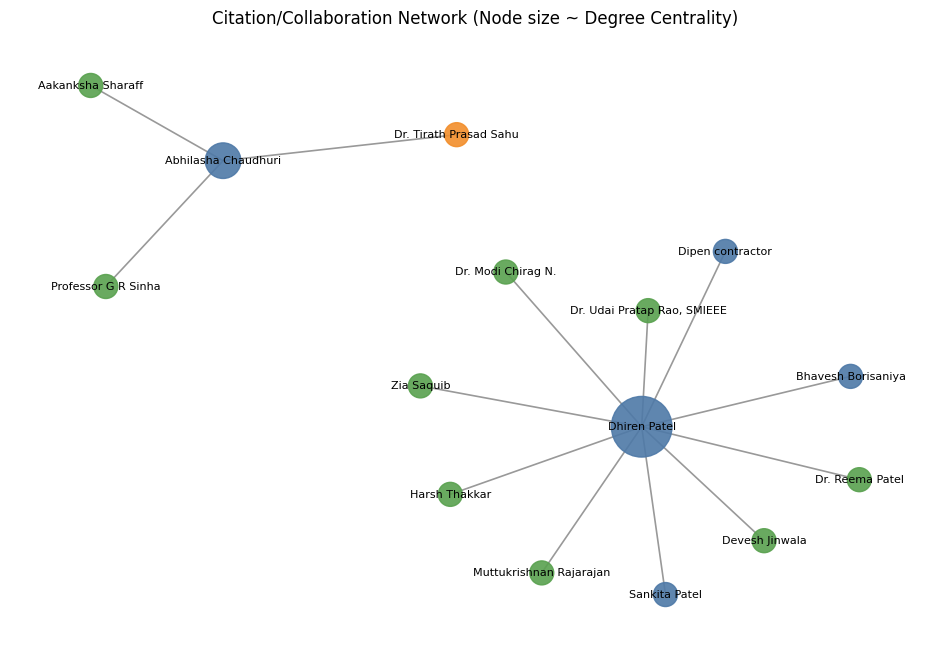

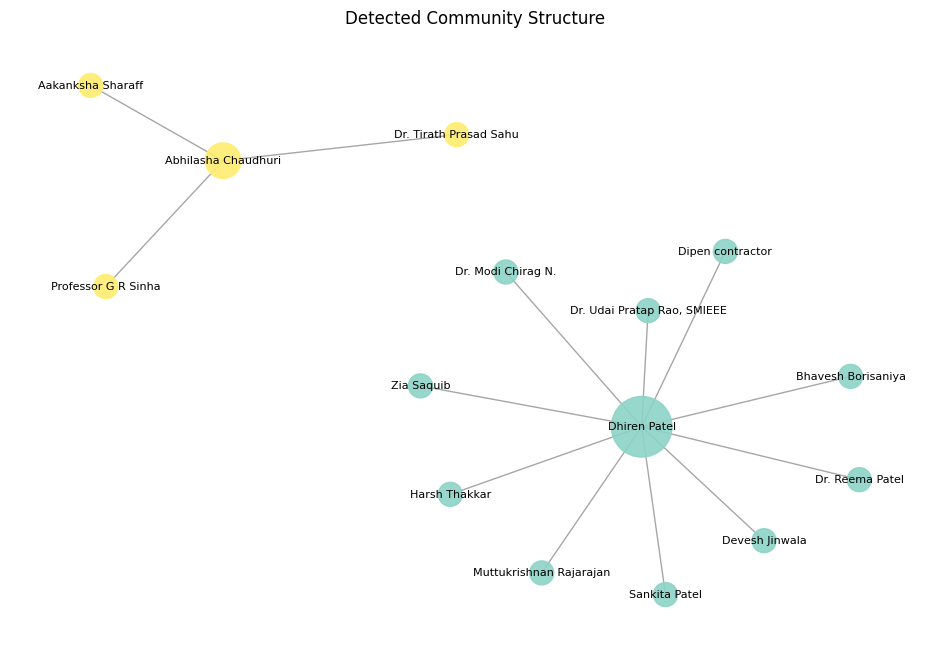

In [16]:
# visualization 1: collaboration graph with institute coloring
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.7)

color_map = []
for n in G.nodes():
    inst = str(G.nodes[n].get("institute", "Unknown"))
    if inst == "SVNIT":
        color_map.append("#4E79A7")
    elif inst == institute_x_name:
        color_map.append("#F28E2B")
    else:
        color_map.append("#59A14F")

sizes = [2500 * deg_cent.get(n, 0) + 120 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.4, width=1.2)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Citation/Collaboration Network (Node size ~ Degree Centrality)")
plt.axis("off")
plt.show()

# visualization 2: community-colored network
if communities:
    plt.figure(figsize=(12, 8))
    comm_colors = [community_map.get(n, 0) for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=comm_colors, cmap=plt.cm.Set3, node_size=sizes, alpha=0.9)
    nx.draw_networkx_edges(G, pos, alpha=0.35)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title("Detected Community Structure")
    plt.axis("off")
    plt.show()


## Findings Summary

- Data source: Google Scholar profiles using IDs `3C5Hs_8AAAAJ` and `rIdRniwAAAAJ`
- Detected collaborator institute (Institute_X): **National Institute of Technology Raipur**
- Nodes: **15**, Edges: **13**
- Density: **0.1238**, Components: **2**, Largest component: **11**
- Highest degree centrality: **Dhiren Patel** (0.7143)
- Highest influence (eigenvector): **Dhiren Patel** (0.7071)
- Communities detected: **2**

### Institute-wise observation
- Cross-institute links were found between SVNIT and multiple external institutes.
- Strongest collaborator institute by coauthor affiliation frequency was **NIT Raipur**.
- The graph shows one dominant collaboration star centered around **Dhiren Patel** and one smaller group around **Abhilasha Chaudhuri**.

### Runtime note
- Scholar scraping can be slow due to anti-bot checks/captcha.
- Fast mode is enabled (limited coauthor/profile lookups) to keep fetch time manageable.